# EDA and Customer Type Split

This notebook focuses on:
1. Basic EDA
2. Identifying one-time vs repeat customers
3. Exporting separate CSV files for each group

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [2]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

df = (customers
      .merge(orders, on='customer_id', how='left')
      .merge(payments, on='order_id', how='left')
      .merge(reviews, on='order_id', how='left'))

df = df[df['order_status'] == 'delivered'].copy()
df.dropna(subset=['payment_value', 'review_score', 'order_delivered_customer_date'], inplace=True)

for c in ['order_purchase_timestamp', 'order_delivered_customer_date']:
    df[c] = pd.to_datetime(df[c])

print(f'Merged delivered dataset shape: {df.shape}')
print(f'Unique customers: {df["customer_unique_id"].nunique():,}')

Merged delivered dataset shape: (100641, 22)
Unique customers: 92,746


In [3]:
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

customer_data = df.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    total_orders=('order_id', 'count'),
    total_spent=('payment_value', 'sum'),
    avg_review=('review_score', 'mean'),
    min_review=('review_score', 'min'),
    pct_low_review=('review_score', lambda x: (x <= 2).mean()),
    avg_payment=('payment_value', 'mean'),
    payment_types=('payment_type', 'nunique')
).reset_index()

customer_data['buyer_type'] = np.where(customer_data['total_orders'] == 1, 'One-Time', 'Repeat')

# Label logic: more conservative for one-time buyers
customer_data['churned'] = np.where(
    customer_data['buyer_type'] == 'One-Time',
    (customer_data['recency_days'] > 210).astype(int),
    (customer_data['recency_days'] > 180).astype(int)
).astype(int)

print(customer_data['buyer_type'].value_counts().to_string())
print(f"Overall churn (new label): {customer_data['churned'].mean()*100:.1f}%")

buyer_type
One-Time    87256
Repeat       5490
Overall churn (new label): 52.3%


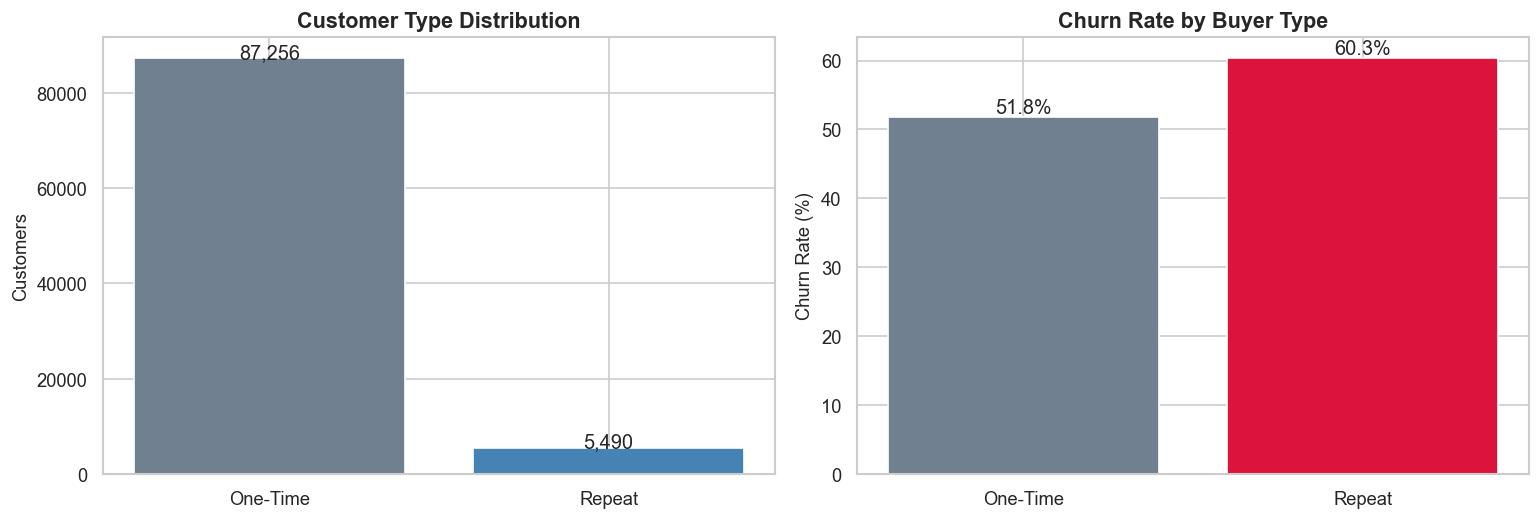

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

buyer_counts = customer_data['buyer_type'].value_counts()
axes[0].bar(buyer_counts.index, buyer_counts.values, color=['slategray', 'steelblue'])
axes[0].set_title('Customer Type Distribution', fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(buyer_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center')

churn_by_type = customer_data.groupby('buyer_type')['churned'].mean().reindex(['One-Time', 'Repeat']) * 100
axes[1].bar(churn_by_type.index, churn_by_type.values, color=['slategray', 'crimson'])
axes[1].set_title('Churn Rate by Buyer Type', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_by_type.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

In [5]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

one_time_customers = customer_data[customer_data['buyer_type'] == 'One-Time'].copy()
repeat_customers = customer_data[customer_data['buyer_type'] == 'Repeat'].copy()

one_time_path = output_dir / 'one_time_customers.csv'
repeat_path = output_dir / 'repeat_customers.csv'

one_time_customers.to_csv(one_time_path, index=False)
repeat_customers.to_csv(repeat_path, index=False)

print(f'Exported one-time customers: {len(one_time_customers):,} -> {one_time_path}')
print(f'Exported repeat customers  : {len(repeat_customers):,} -> {repeat_path}')

Exported one-time customers: 87,256 -> output\one_time_customers.csv
Exported repeat customers  : 5,490 -> output\repeat_customers.csv
